[*] Starting Neural Model Evaluation...
📊 Evaluation Plots saved to: C:\Users\Aamir Khan\Documents\Cybersecurity Threat Detection System\data\evaluation_results.png


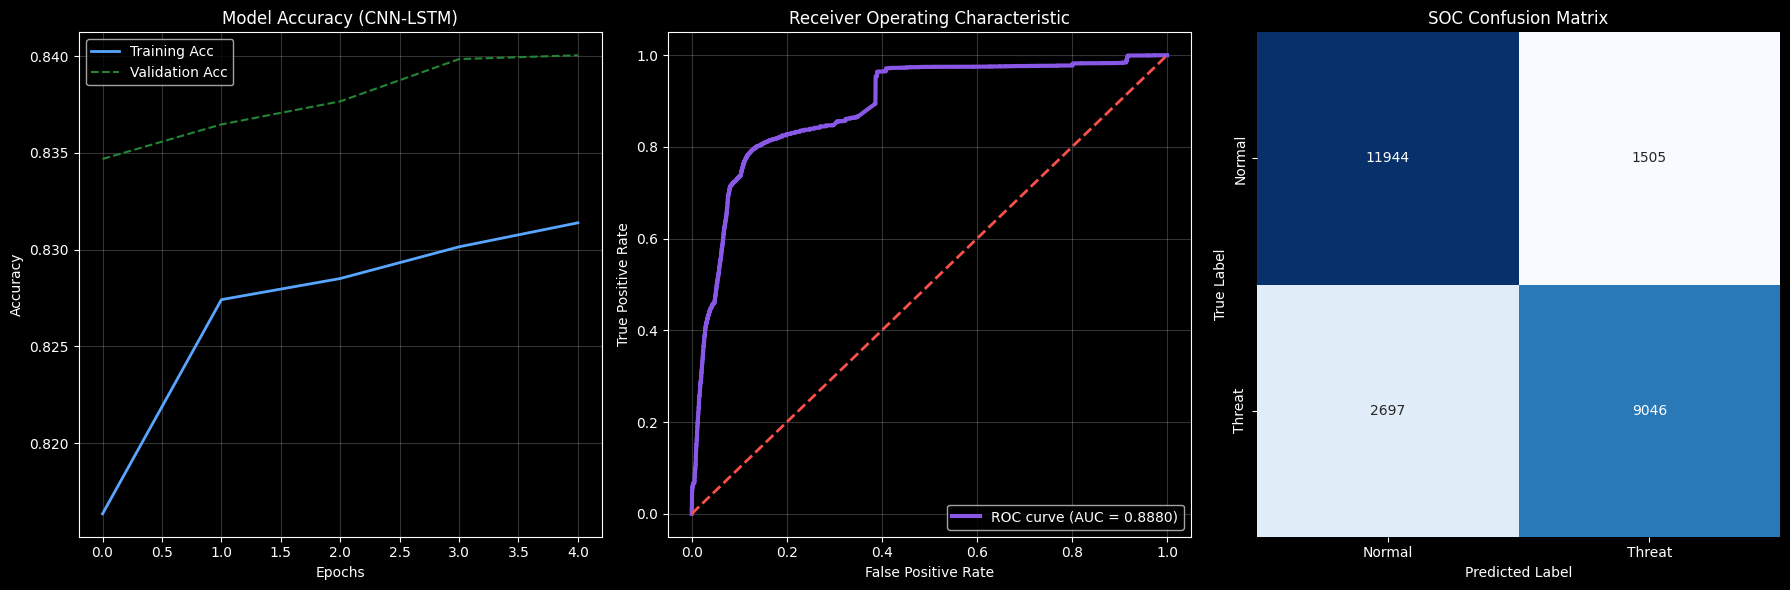


      GUARDNET CLASSIFICATION REPORT
              precision    recall  f1-score   support

      Normal       0.82      0.89      0.85     13449
      Threat       0.86      0.77      0.81     11743

    accuracy                           0.83     25192
   macro avg       0.84      0.83      0.83     25192
weighted avg       0.84      0.83      0.83     25192



In [3]:
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, roc_curve, auc, confusion_matrix

# --- Paths ---
BASE_PATH = os.path.join(os.path.expanduser("~"), "Documents", "Cybersecurity Threat Detection System")
DATA_DIR = os.path.join(BASE_PATH, "data")
MODEL_PATH = os.path.join(BASE_PATH, "backend", "models", "ransomware_lstm.h5")

def run_evaluation():
    print("[*] Starting Neural Model Evaluation...")
    
    # 1. Load Data & Model
    if not os.path.exists(MODEL_PATH):
        print(f"🚨 Error: Model not found at {MODEL_PATH}")
        return

    X = np.load(os.path.join(DATA_DIR, "X_PROCESSED.npy"))
    y = np.load(os.path.join(DATA_DIR, "y_LABELS.npy"))
    
    # Training history load karo plots ke liye
    history_path = os.path.join(DATA_DIR, "train_history.npy")
    if os.path.exists(history_path):
        history = np.load(history_path, allow_pickle=True).item()
    else:
        print("⚠️ Warning: train_history.npy missing. Accuracy plots skipped.")
        history = None

    model = tf.keras.models.load_model(MODEL_PATH)
    
    # 2. Predictions
    y_pred_prob = model.predict(X, verbose=0)
    y_pred = (y_pred_prob > 0.5).astype(int)

    # --- VISUALIZATION BLOCK ---
    plt.style.use('dark_background') # SOC Terminal jaisa look dene ke liye
    fig = plt.figure(figsize=(18, 6))

    # A. Accuracy Trend
    if history:
        plt.subplot(1, 3, 1)
        plt.plot(history['accuracy'], label='Training Acc', color='#58a6ff', linewidth=2)
        plt.plot(history['val_accuracy'], label='Validation Acc', color='#238636', linestyle='--')
        plt.title('Model Accuracy (CNN-LSTM)')
        plt.xlabel('Epochs')
        plt.ylabel('Accuracy')
        plt.legend()
        plt.grid(alpha=0.2)

    # B. ROC Curve (Sensitivity Analysis)
    fpr, tpr, _ = roc_curve(y, y_pred_prob)
    roc_auc = auc(fpr, tpr)
    plt.subplot(1, 3, 2)
    plt.plot(fpr, tpr, color='#8957e5', lw=3, label=f'ROC curve (AUC = {roc_auc:.4f})')
    plt.plot([0, 1], [0, 1], color='#f85149', lw=2, linestyle='--')
    plt.title('Receiver Operating Characteristic')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend(loc="lower right")
    plt.grid(alpha=0.2)

    # C. Confusion Matrix (Heatmap)
    plt.subplot(1, 3, 3)
    cm = confusion_matrix(y, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['Normal', 'Threat'], yticklabels=['Normal', 'Threat'])
    plt.title('SOC Confusion Matrix')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')

    plt.tight_layout()
    
    # Save results as image for Documentation
    eval_plot_path = os.path.join(DATA_DIR, "evaluation_results.png")
    plt.savefig(eval_plot_path)
    print(f"📊 Evaluation Plots saved to: {eval_plot_path}")
    plt.show()

    # 3. Text Report
    print("\n" + "="*50)
    print("      GUARDNET CLASSIFICATION REPORT")
    print("="*50)
    print(classification_report(y, y_pred, target_names=['Normal', 'Threat']))
    print("="*50)

if __name__ == "__main__":
    run_evaluation()